In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("../datasets/aac_intakes_outcomes.csv")


In [3]:
df.head(5)
df.shape

(79672, 41)

In [4]:
df["outcome_type"].unique()

<StringArray>
['Return to Owner',        'Transfer',        'Adoption',      'Euthanasia',
            'Died',       'Rto-Adopt',         'Missing',        'Disposal',
               nan,        'Relocate']
Length: 10, dtype: str

In [5]:
#Remove columns
df = df.drop(columns=["age_upon_outcome_(years)", "age_upon_outcome_age_group", "outcome_month", "outcome_year", "outcome_monthyear", "outcome_weekday", "outcome_hour", "outcome_number", "dob_monthyear", "count", "age_upon_intake_(years)", "age_upon_intake_age_group", "intake_month", "intake_year", "intake_monthyear", "intake_weekday", "intake_hour", "time_in_shelter_days", "dob_year", "dob_month", "age_upon_intake"])

In [6]:
#Check for duplicate rows
df = df.drop_duplicates()
df.shape


(79637, 20)

In [7]:
# Change foster adoptions to foster and drop outcome_subtype
foster_adoptions = (df["outcome_type"] == "Adoption") & (df["outcome_subtype"] == "Foster")
df.loc[foster_adoptions, "outcome_type"] = "Foster"
df = df.drop(columns=["outcome_subtype"])
#df.isna().sum()


In [8]:
#convert age_upon_outcome_(days) and age_upon_intake_(days) to age_upon_outcome_(years) and age_upon_intake_(years)
df["age_upon_outcome_(years)"] = df["age_upon_outcome_(days)"] / 365
df["age_upon_intake_(years)"] = df["age_upon_intake_(days)"] / 365
df = df.drop(columns=["age_upon_outcome_(days)", "age_upon_intake_(days)"])

df.head(5)

,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_type,sex_upon_outcome,outcome_datetime,animal_id_intake,animal_type,breed,color,found_location,intake_condition,intake_type,sex_upon_intake,intake_datetime,intake_number,time_in_shelter,age_upon_outcome_(years),age_upon_intake_(years)
0,10 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2017-12-07 14:07:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,Colony Creek And Hunters Trace in Austin (TX),Normal,Stray,Neutered Male,2017-12-07 00:00:00,1.0,0 days 14:07:00.000000000,10.0,10.0
1,7 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2014-12-20 16:35:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,8700 Research Blvd in Austin (TX),Normal,Public Assist,Neutered Male,2014-12-19 10:21:00,2.0,1 days 06:14:00.000000000,7.0,7.0
2,6 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2014-03-08 17:10:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,8700 Research in Austin (TX),Normal,Public Assist,Neutered Male,2014-03-07 14:26:00,3.0,1 days 02:44:00.000000000,6.0,6.0
3,10 years,A047759,2004-04-02 00:00:00,Transfer,Neutered Male,2014-04-07 15:12:00,A047759,Dog,Dachshund,Tricolor,Austin (TX),Normal,Owner Surrender,Neutered Male,2014-04-02 15:55:00,1.0,4 days 23:17:00.000000000,10.0,10.0
4,16 years,A134067,1997-10-16 00:00:00,Return to Owner,Neutered Male,2013-11-16 11:54:00,A134067,Dog,Shetland Sheepdog,Brown/White,12034 Research Blvd in Austin (TX),Injured,Public Assist,Neutered Male,2013-11-16 09:02:00,1.0,0 days 02:52:00.000000000,16.0,16.0


In [9]:
# Convert time_in_shelter to numeric values
df["time_in_shelter"] = pd.to_timedelta(df["time_in_shelter"])
df["time_in_shelter_days"] = df["time_in_shelter"].dt.total_seconds() / (60 * 60 * 24)

df.head(5)

,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_type,sex_upon_outcome,outcome_datetime,animal_id_intake,animal_type,breed,color,found_location,intake_condition,intake_type,sex_upon_intake,intake_datetime,intake_number,time_in_shelter,age_upon_outcome_(years),age_upon_intake_(years),time_in_shelter_days
0,10 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2017-12-07 14:07:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,Colony Creek And Hunters Trace in Austin (TX),Normal,Stray,Neutered Male,2017-12-07 00:00:00,1.0,0 days 14:07:00,10.0,10.0,0.588194
1,7 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2014-12-20 16:35:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,8700 Research Blvd in Austin (TX),Normal,Public Assist,Neutered Male,2014-12-19 10:21:00,2.0,1 days 06:14:00,7.0,7.0,1.259722
2,6 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2014-03-08 17:10:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,8700 Research in Austin (TX),Normal,Public Assist,Neutered Male,2014-03-07 14:26:00,3.0,1 days 02:44:00,6.0,6.0,1.113889
3,10 years,A047759,2004-04-02 00:00:00,Transfer,Neutered Male,2014-04-07 15:12:00,A047759,Dog,Dachshund,Tricolor,Austin (TX),Normal,Owner Surrender,Neutered Male,2014-04-02 15:55:00,1.0,4 days 23:17:00,10.0,10.0,4.970139
4,16 years,A134067,1997-10-16 00:00:00,Return to Owner,Neutered Male,2013-11-16 11:54:00,A134067,Dog,Shetland Sheepdog,Brown/White,12034 Research Blvd in Austin (TX),Injured,Public Assist,Neutered Male,2013-11-16 09:02:00,1.0,0 days 02:52:00,16.0,16.0,0.119444


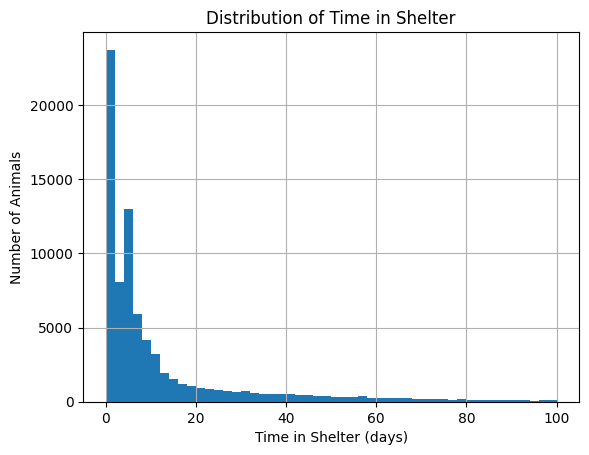

In [10]:
#Distribution of time in shelter
# Shows how many animals stayed in the shelter for different numbers of days (up to 100 to zoom in)
df[df["time_in_shelter_days"] <= 100]["time_in_shelter_days"].hist(bins=50)
plt.xlabel("Time in Shelter (days)")
plt.ylabel("Number of Animals")
plt.title("Distribution of Time in Shelter")
plt.show()

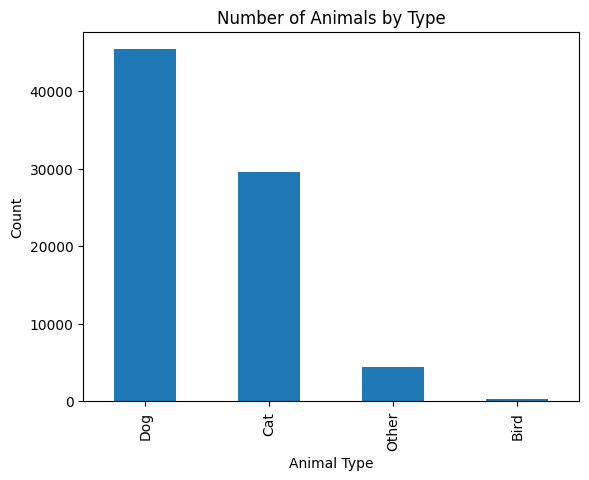

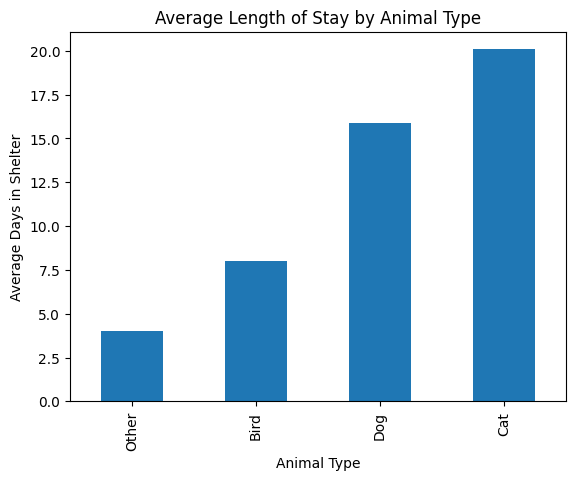

,count,mean,median
animal_type,,,
Cat,29523,20.081548,5.839583
Dog,45353,15.900761,5.064583
Bird,339,8.004333,3.919444
Other,4422,4.023431,0.355903


In [11]:
#Count how many animals are in each animal type category
df["animal_type"].value_counts().plot(kind="bar")
plt.xlabel("Animal Type")
plt.ylabel("Count")
plt.title("Number of Animals by Type")
plt.show()

#Calculate average length of stay for each animal type
df.groupby("animal_type")["time_in_shelter_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Animal Type")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Animal Type")
plt.show()

df.groupby("animal_type")["time_in_shelter_days"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

#Intepretation: 
# Dogs is the largest number of animals in the data. 
# Cats have the highest average length of stay

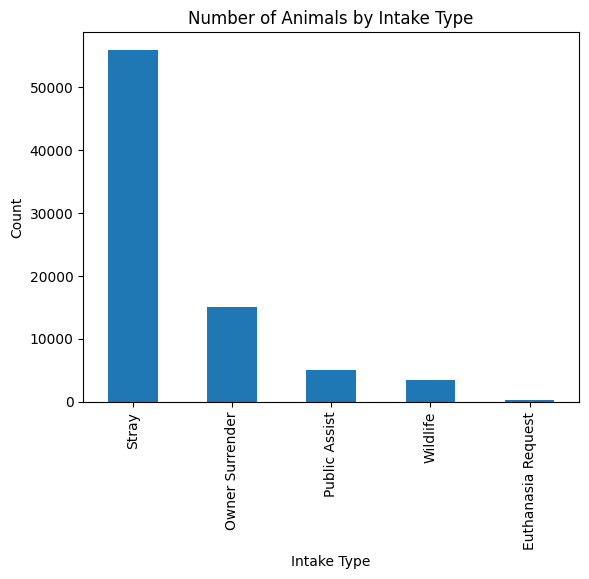

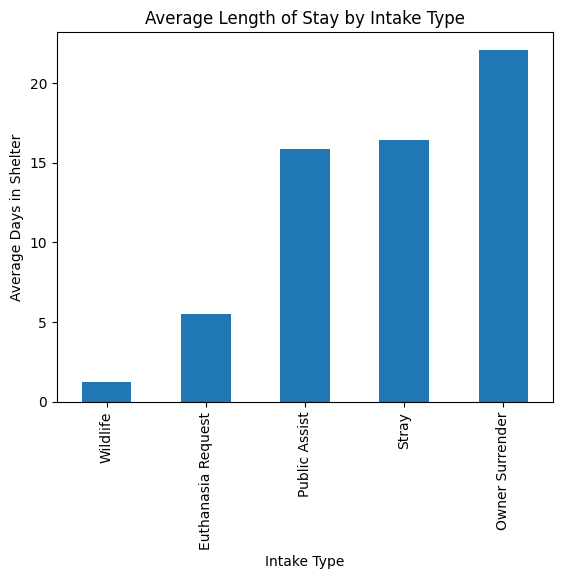

In [ ]:
# Distribution of intake types
# Shows how many animals came into the shelter for each intake type
df["intake_type"].value_counts().plot(kind="bar")
plt.xlabel("Intake Type")
plt.ylabel("Count")
plt.title("Number of Animals by Intake Type")
plt.show()

# Average length of stay by intake type
# Shows which intake types have longer/shorter stays
df.groupby("intake_type")["time_in_shelter_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Intake Type")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Intake Type")
plt.show()

# Interpretation:
# Stray animals make up the largest intake group. 
# However, owner surrendered animals have the highest average length of stay
# intake type may be useful for predicting how long an animal stays in shelter.

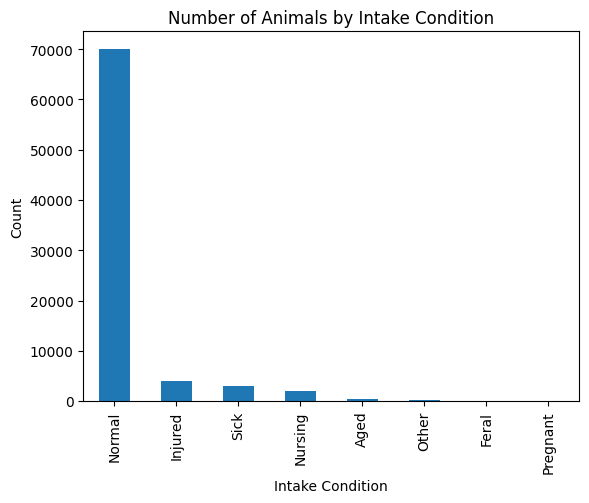

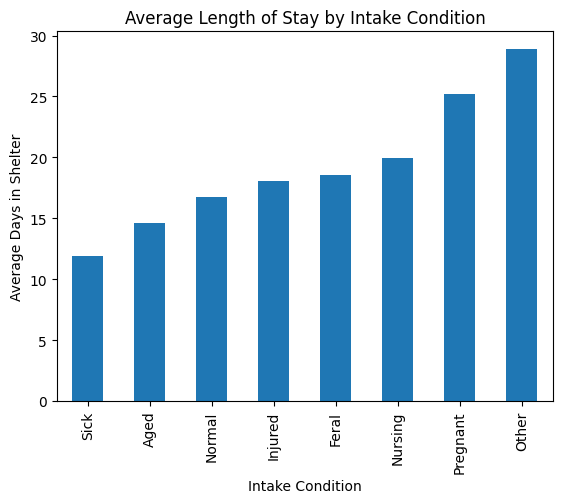

,count,mean,median
intake_condition,,,
Other,147,28.887023,4.322222
Pregnant,47,25.192479,5.975694
Nursing,1913,19.981175,1.272917
Feral,92,18.587575,6.053472
Injured,3996,18.064104,3.254514
Normal,70027,16.787384,5.097222
Aged,319,14.577841,2.030556
Sick,3096,11.870391,0.669792


In [ ]:
# Distribution of intake conditions
# Shows how many animals came into the shelter under each condition
df["intake_condition"].value_counts().plot(kind="bar")
plt.xlabel("Intake Condition")
plt.ylabel("Count")
plt.title("Number of Animals by Intake Condition")
plt.show()

# Average length of stay by intake condition
# Shows which intake conditions have longer/shorter stays
df.groupby("intake_condition")["time_in_shelter_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Intake Condition")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Intake Condition")
plt.show()

df.groupby("intake_condition")["time_in_shelter_days"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

# Interpretation:
# Most animals enter shelter in normal conditions. 
# Animals with less common intake conditions have higher stays
# Could be useful for prediciting length of stay

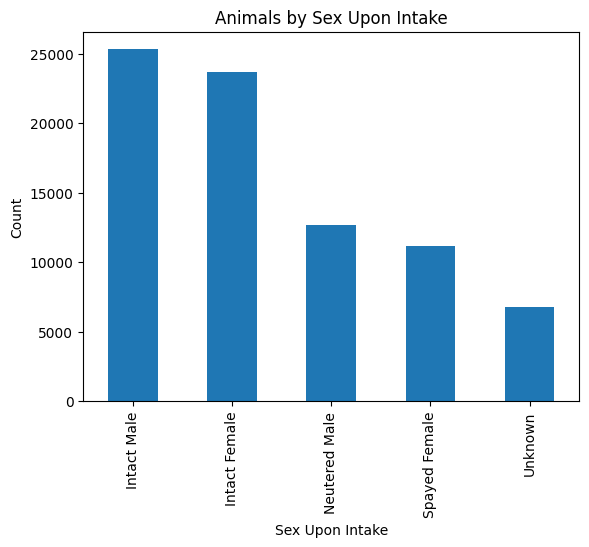

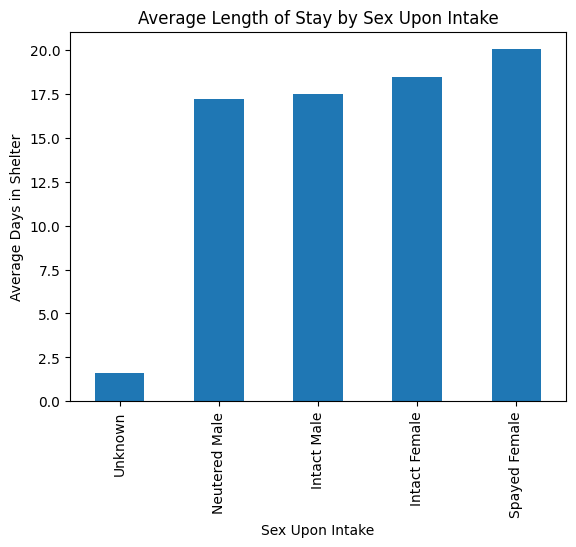

,count,mean,median
sex_upon_intake,,,
Spayed Female,11145,20.046873,4.972917
Intact Female,23701,18.484188,5.425694
Intact Male,25308,17.520545,5.930208
Neutered Male,12700,17.223217,4.864583
Unknown,6782,1.599640,0.140278


In [20]:
# Distribution of sex/neuter status
# Shows how many animals fall into each category sex and neuter/spay category at intake
df["sex_upon_intake"].value_counts().plot(kind="bar")
plt.xlabel("Sex Upon Intake")
plt.ylabel("Count")
plt.title("Animals by Sex Upon Intake")
plt.show()

# Average length of stay by sex/neuter status upon intake
df.groupby("sex_upon_intake")["time_in_shelter_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Sex Upon Intake")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Sex Upon Intake")
plt.show()

df.groupby("sex_upon_intake")["time_in_shelter_days"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

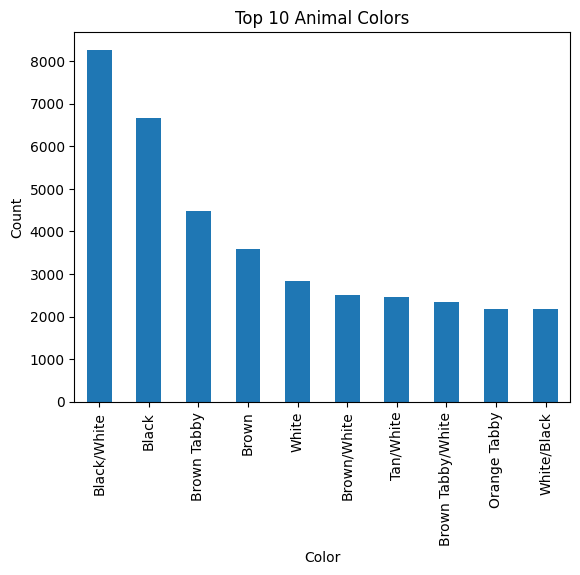

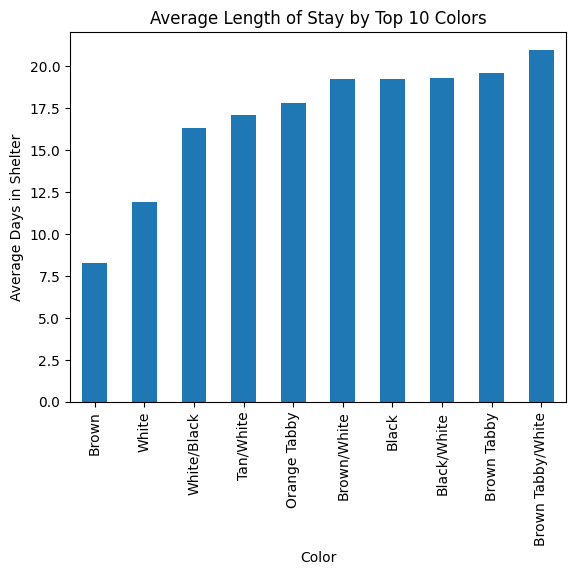

,count,mean,median
color,,,
Brown Tabby/White,2351,20.999111,6.277083
Brown Tabby,4469,19.581699,5.212500
Black/White,8267,19.287604,5.212500
Black,6671,19.228257,5.184722
Brown/White,2515,19.225479,5.353472
Orange Tabby,2182,17.813770,5.117361
Tan/White,2462,17.093060,5.101042
White/Black,2170,16.358615,5.159722
White,2835,11.943711,4.272222


In [24]:
# Get top 10 most common colors (because there are a lot)
top_colors = df["color"].value_counts().head(10).index

# Distribution of top 10 colors 
# Shows which color appears most
df[df["color"].isin(top_colors)]["color"].value_counts().plot(kind="bar")
plt.xlabel("Color")
plt.ylabel("Count")
plt.title("Top 10 Animal Colors")
plt.show()

# Average length of stay by top 10 colors
# Shows whether certain animal colors have higher/lower stays 
df[df["color"].isin(top_colors)].groupby("color")["time_in_shelter_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Color")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Top 10 Colors")
plt.show()

# Summary statistics for length of stay by top 10 colors
df[df["color"].isin(top_colors)].groupby("color")["time_in_shelter_days"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)



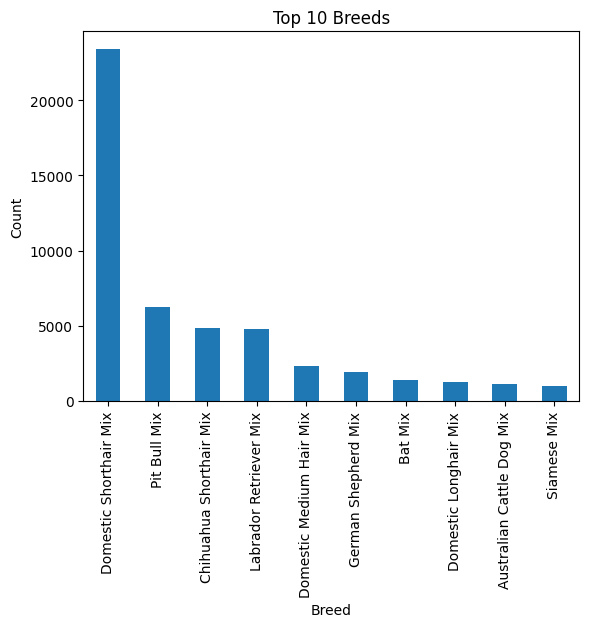

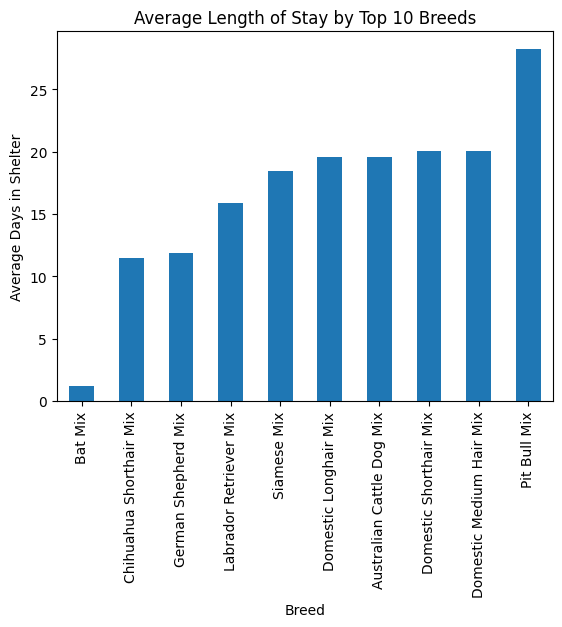

In [ ]:
# Get top 10 breeds (because there are a lot)
top_breeds = df["breed"].value_counts().head(10).index

# Distribution of top 10 breeds
# Shows which breed appears most often
df[df["breed"].isin(top_breeds)]["breed"].value_counts().plot(kind="bar")
plt.xlabel("Breed")
plt.ylabel("Count")
plt.title("Top 10 Breeds")
plt.show()

# Average length of stay by top 10 breeds
df[df["breed"].isin(top_breeds)].groupby("breed")["time_in_shelter_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Breed")
plt.ylabel("Average Days in Shelter")
plt.title("Average Length of Stay by Top 10 Breeds")
plt.show()

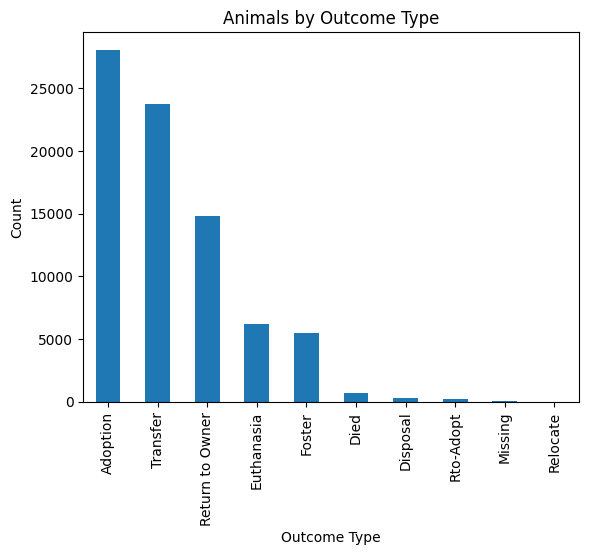

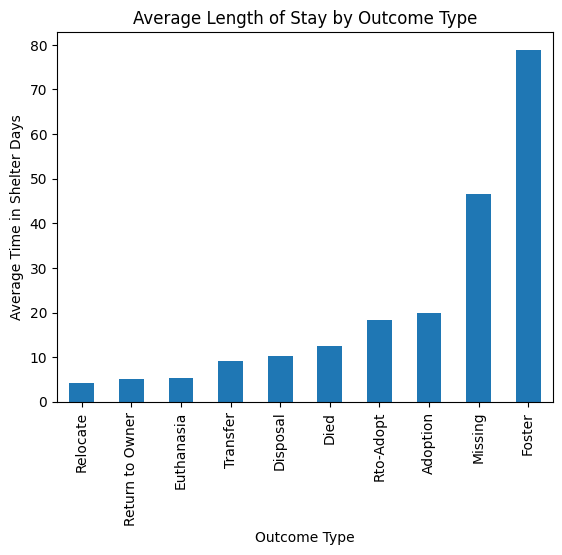

In [ ]:
# Distribution of top 10 breeds
df["outcome_type"].value_counts().plot(kind="bar")
plt.xlabel("Outcome Type")
plt.ylabel("Count")
plt.title("Animals by Outcome Type")
plt.show()

# Average length of stay by outcome type
df.groupby("outcome_type")["time_in_shelter_days"].mean().sort_values().plot(kind="bar")
plt.xlabel("Outcome Type")
plt.ylabel("Average Time in Shelter Days")
plt.title("Average Length of Stay by Outcome Type")
plt.show()



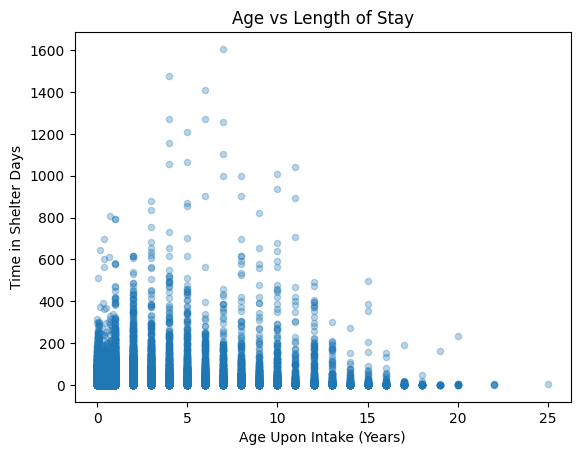

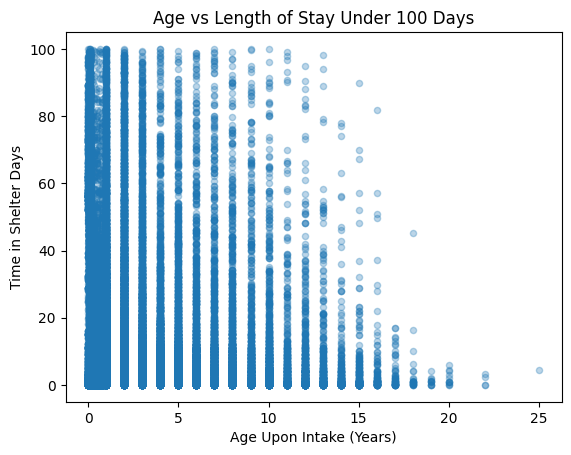

In [ ]:
#Compare age and time_in_shelter
df.plot(
    kind="scatter",
    x="age_upon_intake_(years)",
    y="time_in_shelter_days",
    alpha=0.3
)

plt.xlabel("Age Upon Intake (Years)")
plt.ylabel("Time in Shelter Days")
plt.title("Age vs Length of Stay")
plt.show()


df_zoom = df[df["time_in_shelter_days"] <= 100]

df_zoom.plot(
    kind="scatter",
    x="age_upon_intake_(years)",
    y="time_in_shelter_days",
    alpha=0.3
)

plt.xlabel("Age Upon Intake (Years)")
plt.ylabel("Time in Shelter Days")
plt.title("Age vs Length of Stay Under 100 Days")
plt.show()

In [ ]:
#Compare dog vs cat and time_in_shelter
dog_cat = df[df["animal_type"].isin(["Dog", "Cat"])]


dog_cat.groupby("animal_type")["time_in_shelter_days"].mean().plot(kind="bar")
plt.xlabel("Animal Type")
plt.ylabel("Average Time in Shelter Days")
plt.title("Average Length of Stay: Dogs vs Cats")
plt.show()


dog_cat.groupby("animal_type")["time_in_shelter_days"].median().plot(kind="bar")
plt.xlabel("Animal Type")
plt.ylabel("Median Time in Shelter Days")
plt.title("Median Length of Stay: Dogs vs Cats")
plt.show()

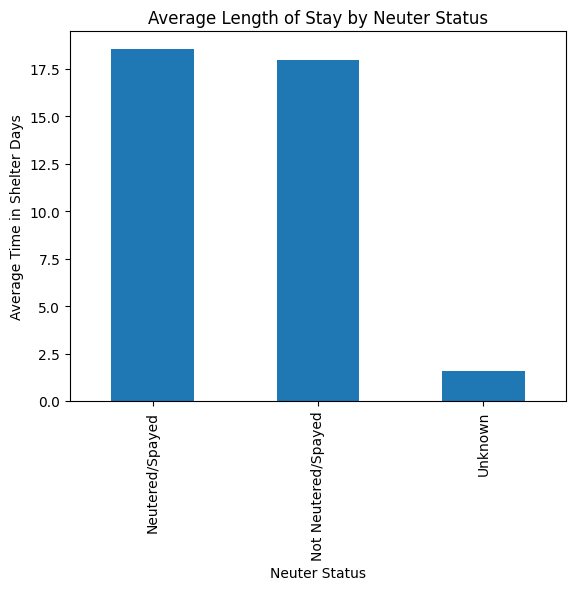

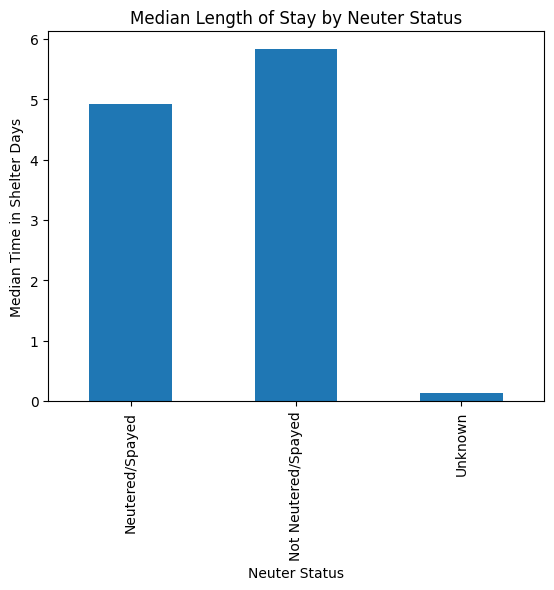

In [ ]:
#Compare neutered vs not neutered and time_in_shelter

def neuter_status(sex):
    if "Neutered" in str(sex) or "Spayed" in str(sex):
        return "Neutered/Spayed"
    elif "Intact" in str(sex):
        return "Not Neutered/Spayed"
    else:
        return "Unknown"

df["neuter_status"] = df["sex_upon_intake"].apply(neuter_status)

df.groupby("neuter_status")["time_in_shelter_days"].mean().plot(kind="bar")

plt.xlabel("Neuter Status")
plt.ylabel("Average Time in Shelter Days")
plt.title("Average Length of Stay by Neuter Status")
plt.show()


df.groupby("neuter_status")["time_in_shelter_days"].median().plot(kind="bar")
plt.xlabel("Neuter Status")
plt.ylabel("Median Time in Shelter Days")
plt.title("Median Length of Stay by Neuter Status")
plt.show()

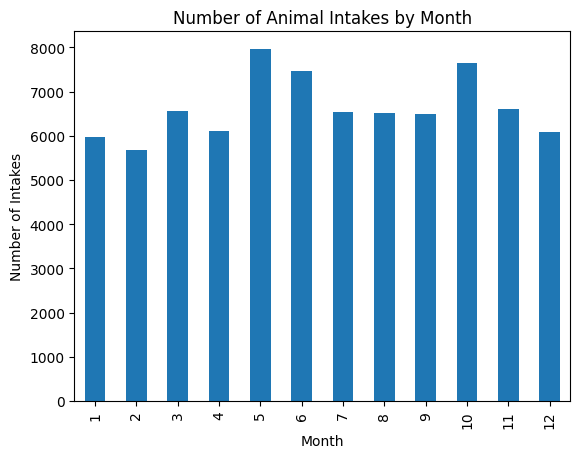

In [ ]:
#Count intakes by month
df["intake_datetime"] = pd.to_datetime(df["intake_datetime"])
df["intake_month"] = df["intake_datetime"].dt.month

df["intake_month"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Number of Intakes")
plt.title("Number of Animal Intakes by Month")
plt.show()

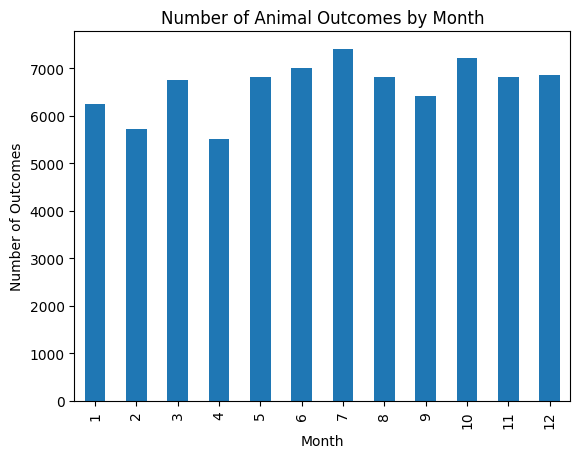

In [ ]:
#Count outcomes by month
df["outcome_datetime"] = pd.to_datetime(df["outcome_datetime"])
df["outcome_month"] = df["outcome_datetime"].dt.month

df["outcome_month"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Month")
plt.ylabel("Number of Outcomes")
plt.title("Number of Animal Outcomes by Month")
plt.show()